<a href="https://colab.research.google.com/github/ahmadtanoli2004/00_Project/blob/main/Unsupervised_ML_%26_Deep_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  **Advanced Unsupervised Learning & Deep Learning Project**

### **Table of Contents**

1. Introduction  
2. Import Libraries  

####  **Unsupervised Learning (Customer Segmentation)**
3. Dataset Loading  
4. Data Preprocessing  
5. Feature Engineering  
6. PCA Implementation  
7. SVD Implementation  
8. t-SNE Visualization  
9. GMM Clustering  
10. AIC / BIC Evaluation  

####  **Deep Learning (Bank Marketing)**
11. Dataset Loading  
12. Data Preprocessing  
13. Train-Test Split  
14. Neural Network Model (MLP)  
15. Activation Functions  
16. Model Training  
17. Early Stopping  
18. Model Evaluation  

####  **Advanced Concepts**
19. Machine Learning vs Deep Learning  
20. Overfitting vs Underfitting  
21. Random State  

22. Conclusion  

# **1.Introduction**

In todays data-driven world, organizations rely heavily on data analysis and intelligent systems to make informed decisions. Machine Learning and Deep Learning have become essential tools for extracting meaningful insights from large and complex datasets.

This project focuses on the implementation of both **Unsupervised Learning** and **Deep Learning** techniques on real-world datasets. The primary objective is to explore hidden patterns in customer data and to build predictive models for banking applications.

In the first part of the project, unsupervised learning methods such as PCA, SVD, t-SNE, and Gaussian Mixture Models (GMM) are applied to a customer segmentation dataset. The goal is to identify distinct groups of customers based on their behavior without using labeled data.

In the second part, a Deep Learning approach is used on a bank marketing dataset. A Neural Network (Multi-Layer Perceptron) is developed to predict customer responses, such as whether a customer will subscribe to a service or not.

This project not only demonstrates practical implementation skills but also provides a comparative understanding of traditional machine learning and deep learning techniques. Additionally, important concepts such as overfitting, underfitting, and model reproducibility are discussed.

Overall, this capstone project aims to build a strong foundation in both unsupervised learning and deep learning by combining theory with hands-on implementation.


# **2.Import Libraries**

In [1]:
# Data handling
import numpy as np
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Dimensionality Reduction
from sklearn.decomposition import PCA, TruncatedSVD

# Visualization (Advanced)
from sklearn.manifold import TSNE

# Clustering
from sklearn.mixture import GaussianMixture

# Model Evaluation / Splitting
from sklearn.model_selection import train_test_split

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# **Unsupervised Learning (Customer Segmentation)**

## **3. Dataset Loading**

In [4]:
df_costumer = pd.read_csv('/content/drive/MyDrive/Mall_Customers.csv')

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Mall_Customers.csv'

## **4. Data Preprocessing**

#### **4.1 Understand the Data**


In [ ]:
df_costumer.head()

In [ ]:
df_costumer.info()

In [ ]:
df_costumer.describe()

#### **4.2 Checking Missing Value**

In [ ]:
df_costumer.isnull().sum()

#### **4.3 Selecting Important Features**

In [ ]:
# remove unncessary column
df_costumer.drop(['CustomerID'], axis=1, inplace=True)

#### **4.4 Encoding Categorical Column**

In [ ]:
# convert gender to numeric
df_costumer['Gender'] = df_costumer['Gender'].map({'Male': 1, 'Female': 0})

## **5. Feature Engneering**

In [ ]:
scalar = StandardScaler()
df_costumer_scaled = scalar.fit_transform(df_costumer)
df_costumer_scaled = pd.DataFrame(df_costumer_scaled, columns=df_costumer.columns)
df_costumer_scaled.head()



## **6.PCA Implementation**

#### **6.1 Apply PCA**

In [ ]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
df_costumer_pca = pca.fit_transform(df_costumer_scaled)

#### **6.2 Convert to Dataframe**

In [ ]:
pca = pd.DataFrame(df_costumer_pca, columns=['PC1', 'PC2'])
pca.head()

#### **6.3 Visulization**

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(pca["PC1"], pca["PC2"])
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization of Customer Data")
plt.show()

## **7. SVD Implementation**

#### **7.1 Apply SVD**


In [ ]:
svd = TruncatedSVD(n_components=2)
df_costumer_svd = svd.fit_transform(df_costumer_scaled)

#### **7.2 Convert to Dataframe**

In [ ]:
svd =pd.DataFrame(df_costumer_svd, columns=['SVD1', 'SVD2'])
svd.head()

#### **7.3 Visulization**

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(svd["SVD1"], svd["SVD2"])
plt.xlabel("Singular Vector 1")
plt.ylabel("Singular Vector 2")
plt.title("SVD Visualization of Customer Data")
plt.show()

## **8. t-SNE Visulization**

#### **8.1 Apply t-SNE**

In [ ]:
tsne = TSNE(n_components=2, random_state=42)
tsne_data = tsne.fit_transform(df_costumer_scaled)

#### **8.2 Visulization**

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(tsne_data[:,0], tsne_data[:,1])
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.title("t-SNE Visualization of Customer Data")
plt.show()

## **9. GMM Clustring**

#### **9.1 Apply GMM**

In [ ]:
gmm = GaussianMixture(n_components=5, random_state=42)
gmm.fit(df_costumer_scaled)
gmm_labels = gmm.predict(df_costumer_scaled)
df_costumer['Cluster'] = gmm_labels

#### **9.2 Visulization**

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=tsne_data[:,0],
    y=tsne_data[:,1],
    hue=df_costumer['Cluster'],
    palette='tab10',
    s=100)
plt.title("Customer Segmentation (GMM + t-SNE)")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.legend(title="Clusters")
plt.grid(True)
plt.show()



## **10. AIC/BIC Evauation**

In [ ]:
print("AIC:", gmm.aic(df_costumer_scaled))
print("BIC:", gmm.bic(df_costumer_scaled))



# **Deep Learning (Bank Marketing)**



## **11. Dataset Loading**  

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/bank.csv')

## **12. Data Preprocessing**

#### **12.1 Understand the Data**

In [ ]:
df.head()

In [ ]:
df.info()

In [ ]:
df.describe()

#### **12.2 Checking Missing Value**

In [ ]:
df.isnull().sum()

#### **12.3 Encoding Categorical Columns**

In [ ]:
cat_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)


In [ ]:
df_encoded.head()

## **13. Train_Test & Split**

In [ ]:
X = df_encoded.drop('deposit', axis=1)
y = df_encoded['deposit']

# Convert 'deposit' column from 'yes'/'no' strings to 1/0 numerical values
y = y.map({'yes': 1, 'no': 0})

# Train-Test & Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## **14. Scale the Dataset**

In [ ]:
# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Fix the Data Types
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
y_train = y_train.astype('float32')
y_test = y_test.astype('float32')



## **15. Neural Network Model**

In [ ]:
model = Sequential()
model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))


## **16. Model Training**

In [ ]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.fit(X_train_scaled, y_train, epochs=20, batch_size=128, validation_split=0.2)


## **17. Early Stopping**

In [ ]:
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(X_train_scaled, y_train, epochs=20, batch_size=128, validation_split=0.2, callbacks=[early_stopping])

## **18. Model Evaluation**

In [ ]:
loss, accuracy = model.evaluate(X_test_scaled, y_test)
print(f'Test Loss: {loss:.4f}')
print(f'Test Accuracy: {accuracy:.4f}')

# **Advanced Concepts**

## **19. Machine Learning VS Deep Learning**
Machine Learning (ML) is a technique where models learn patterns from data using simple algorithms and usually require manual feature engineering.
Deep Learning (DL) is a subset of ML that uses neural networks with multiple layers to automatically learn complex patterns from large datasets.
In this project:
ML was used for clustering (PCA, GMM), while DL was used for prediction (Neural Network).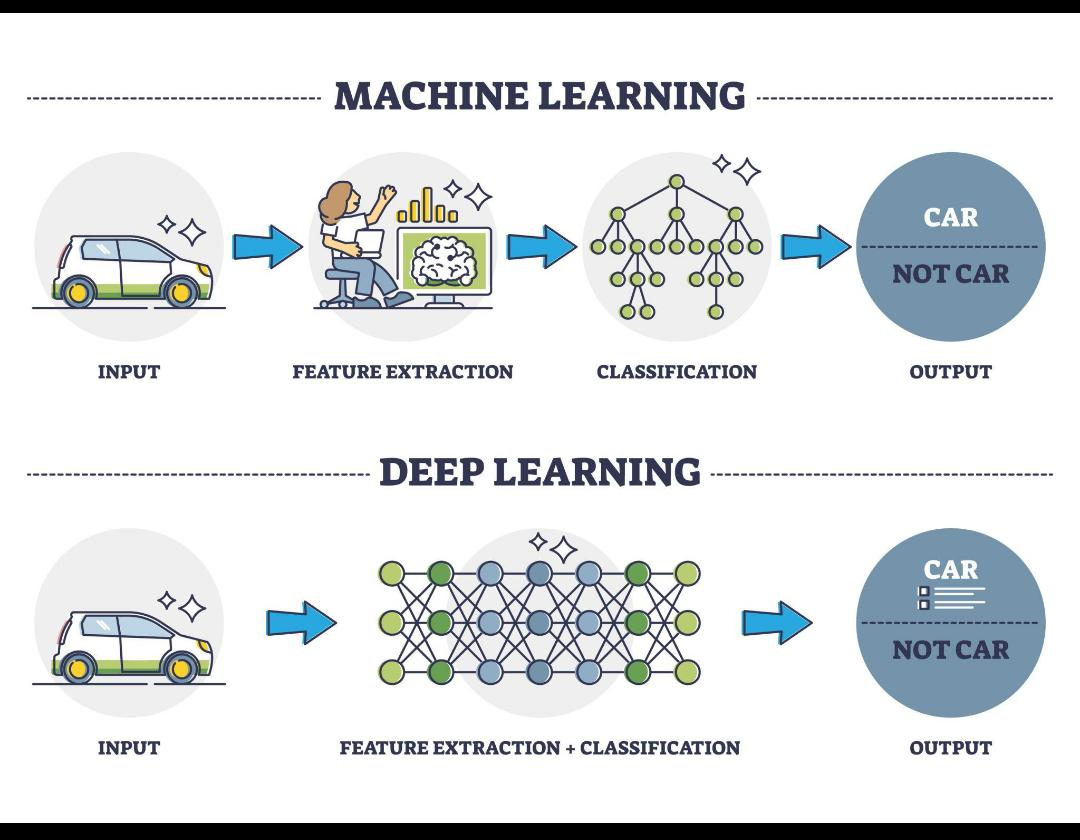

## **20. Overfitting vs Underfitting**
Overfitting occurs when a model learns the training data too well and performs poorly on new data.
Underfitting occurs when a model is too simple and cannot learn the data properly.
Example:
High training accuracy but low validation accuracy = Overfitting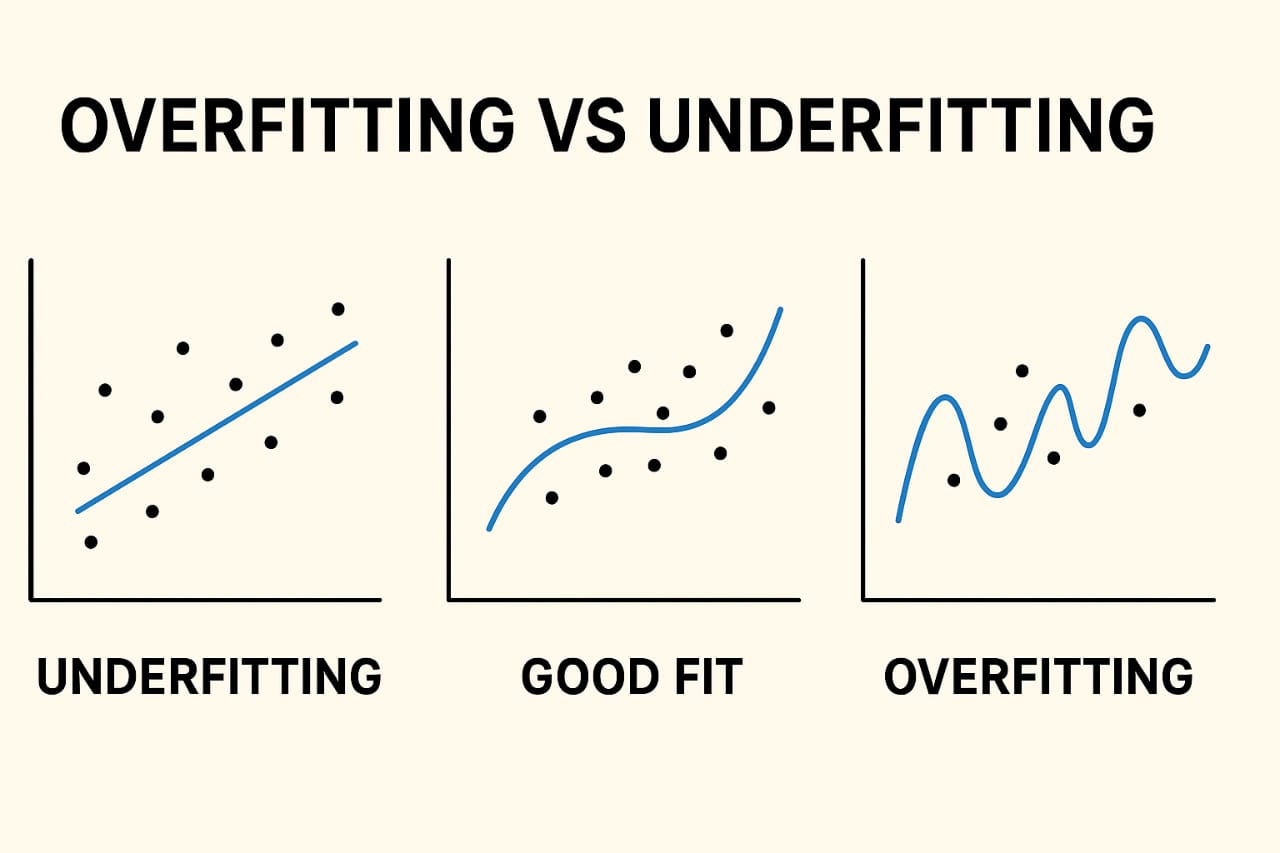

## **21. Random State (Reproducibility)**
Random state is used to make results consistent across multiple runs.
It ensures that the same output is produced every time the code is executed.
Example:
random_state=42

## **22. Conclusion**


This project successfully demonstrated the application of both unsupervised learning and deep learning techniques to real-world datasets. For customer segmentation, dimensionality reduction methods like PCA, SVD, and t-SNE were effectively used to visualize customer data, and GMM clustering helped identify distinct customer groups, which was evaluated using AIC and BIC.

In the deep learning section, a Multi-Layer Perceptron (MLP) model was developed for bank marketing, achieving a good accuracy of approximately 82.71% in predicting customer responses after thorough data preprocessing and using early stopping to prevent overfitting.

Overall, the project provided a comprehensive understanding of these advanced machine learning paradigms, highlighting their practical utility and addressing important concepts such as the differences between ML and DL, overfitting vs. underfitting, and the importance of reproducibility with random states.